In [1]:
# Bibliotecas utilizadas no notebook 01

import os # navegação de pastas e arquivos
import cv2 # processamento de imagens com OpenCV
import numpy as np # operações matemáticas e matrizes
import pandas as pd # manipulação de tabelas de dados
import matplotlib.pyplot as plt # exibição de imagens e gráficos
from pathlib import Path # manipulação de caminhos de forma compatível entre sistemas

In [2]:
# Configuração dos diretórios de entrada e saída

# Caminho da pasta que contém as imagens do dataset de treinamento
# Como o notebook está dentro da pasta "notebooks", é necessário voltar um nível antes de acessar "dataset"
DATASET_PATH = "../dataset/train"

# Diretório onde serão armazenadas as imagens após o processo de segmentação
OUTPUT_PATH = "../outputs/segmented_images"

# Cria automaticamente o diretório de saída caso ele não exista
# O parâmetro exist_ok=True evita erros se a pasta já estiver criada
os.makedirs(OUTPUT_PATH, exist_ok=True)

# Exibe os caminhos configurados para conferência
print("Dataset:", DATASET_PATH)
print("Saída:", OUTPUT_PATH)

Dataset: ../dataset/train
Saída: ../outputs/segmented_images


In [3]:
# Identificação das classes do dataset

# Cada subpasta presente no diretório do dataset representa uma classe
# Exemplos: "Fresh Apple", "Rotten Apple", "Fresh Banana", entre outras
classes = sorted(os.listdir(DATASET_PATH))

# Exibe a lista de classes encontradas no conjunto de dados
print("Classes encontradas:")

for c in classes:
    print(c)

Classes encontradas:
freshapples
freshbanana
freshoranges
rottenapples
rottenbanana
rottenoranges


In [4]:
# Leitura e catalogação das imagens do dataset

# Listas utilizadas para armazenar:
image_paths = [] # o caminho completo de cada imagem
labels = [] # a classe (rótulo) associada à imagem

# Percorre todas as classes identificadas no dataset
for classe in classes:
    # Caminho da pasta correspondente à classe atual
    pasta_classe = os.path.join(DATASET_PATH, classe)

    # Obtém os arquivos presentes na pasta da classe
    arquivos = os.listdir(pasta_classe)

    # Percorre todas as imagens da classe
    for arquivo in arquivos:
        caminho = os.path.join(pasta_classe, arquivo)

        # Armazena o caminho da imagem e seu respectivo rótulo
        image_paths.append(caminho)
        labels.append(classe)

# Exibe a quantidade total de imagens encontradas
print("Quantidade de imagens:", len(image_paths))

Quantidade de imagens: 10901


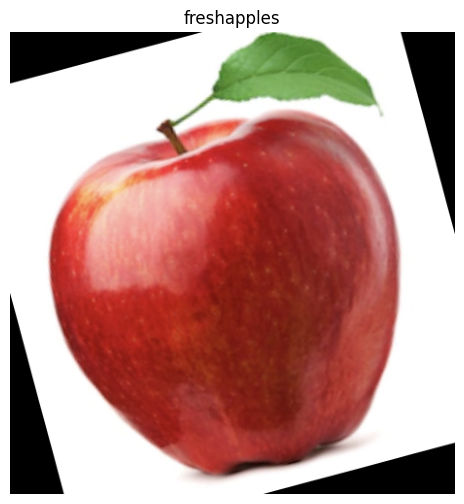

In [5]:
# Visualização de uma amostra do dataset

# Seleciona o índice da imagem que será exibida
idx = 0

# Carrega a imagem utilizando OpenCV
img = cv2.imread(image_paths[idx])

# Converte o padrão de cores de BGR (OpenCV) para RGB para exibição correta com o Matplotlib
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Exibe a imagem e seu respectivo rótulo
plt.figure(figsize=(6,6))
plt.imshow(img)
plt.title(labels[idx])
plt.axis("off")
plt.show()

In [6]:
"""
Segmentação por limiarização automática (Método de Otsu)

O método de Otsu determina automaticamente o valor ideal de limiar (threshold) com base na distribuição dos níveis de
intensidade da imagem. O objetivo é separar o objeto de interesse do fundo, gerando uma máscara binária
"""

def segmentar_otsu(imagem):
    # Converte a imagem RGB para escala de cinza, reduzindo-a para um único canal de intensidade
    gray = cv2.cvtColor(imagem, cv2.COLOR_RGB2GRAY)

    # Aplica a limiarização automática de Otsu
    # THRESH_BINARY_INV inverte os valores da máscara para que o objeto fique em branco (255) e o fundo em preto (0)
    _, mask = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # Retorna a máscara binária resultante da segmentação
    return mask

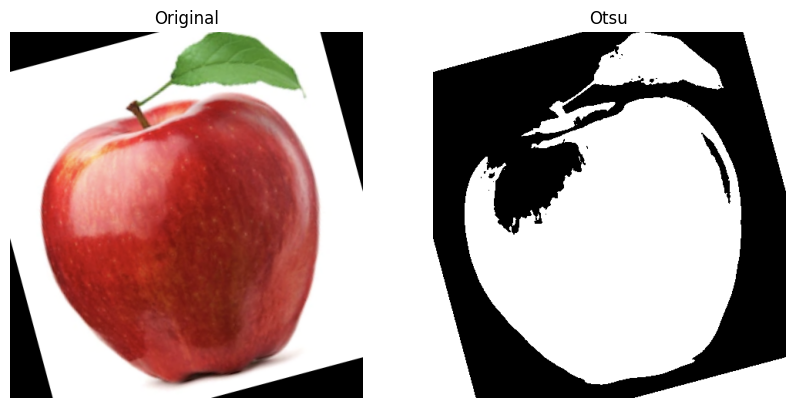

In [7]:
# Teste da segmentação utilizando o método de Otsu
# Esta etapa permite avaliar visualmente o resultado da segmentação, comparando a imagem original com a máscara
# binária gerada pelo algoritmo

# Carrega uma imagem de exemplo do dataset
img = cv2.imread(image_paths[0])

# Converte de BGR para RGB para exibição correta
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Gera a máscara binária utilizando o método de Otsu
mask = segmentar_otsu(img)

# Exibe a imagem original e o resultado da segmentação
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask, cmap="gray")
plt.title("Otsu")
plt.axis("off")

plt.show()

In [8]:
"""
Segmentação baseada em detecção de contornos

O procedimento consiste em:
1. Converter a imagem para escala de cinza
2. Aplicar suavização para reduzir ruídos
3. Gerar uma máscara binária utilizando o método de Otsu
4. Detectar os contornos presentes na imagem
5. Selecionar o maior contorno encontrado, assumindo que ele corresponde ao objeto principal
6. Criar uma máscara preenchida contendo apenas esse objeto
"""

def segmentar_contorno(imagem):
    # Conversão da imagem RGB para escala de cinza
    gray = cv2.cvtColor(imagem, cv2.COLOR_RGB2GRAY)

    # Suavização da imagem para reduzir ruídos e facilitar a detecção dos contornos
    blur = cv2.GaussianBlur(gray, (5,5), 0)

    # Limiarização automática utilizando o método de Otsu
    _, thresh = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # Detecção apenas dos contornos externos da imagem
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Inicializa uma máscara vazia com as mesmas dimensões da imagem em escala de cinza
    mask = np.zeros_like(gray)

    # Verifica se algum contorno foi encontrado
    if len(contours) > 0:
        # Seleciona o contorno com maior área
        maior = max(contours, key=cv2.contourArea)

        # Desenha e preenche o maior contorno na máscara
        cv2.drawContours(mask, [maior], -1, 255, thickness=-1)

    # Retorna a máscara segmentada
    return mask

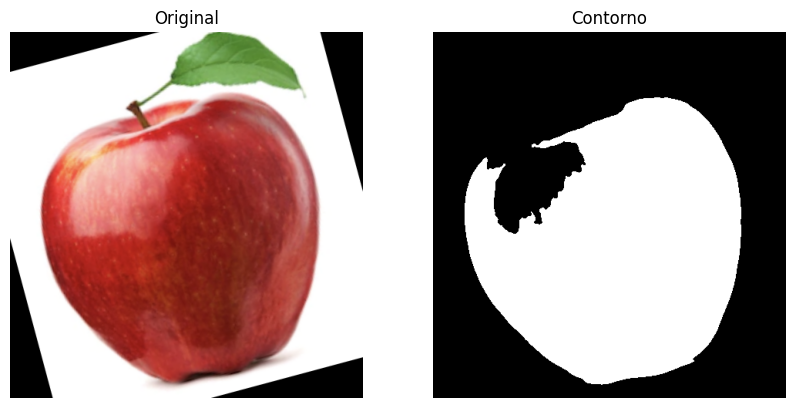

In [9]:
# Teste da segmentação baseada em contornos
# Esta etapa permite verificar visualmente a capacidade do algoritmo em identificar e isolar o objeto principal da
# imagem por meio da detecção do maior contorno

# Carrega uma imagem de exemplo do dataset
img = cv2.imread(image_paths[0])

# Converte de BGR para RGB para exibição correta
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Aplica a segmentação por contornos
mask = segmentar_contorno(img)

# Exibe a imagem original e a máscara gerada
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask, cmap="gray")
plt.title("Contorno")
plt.axis("off")

plt.show()

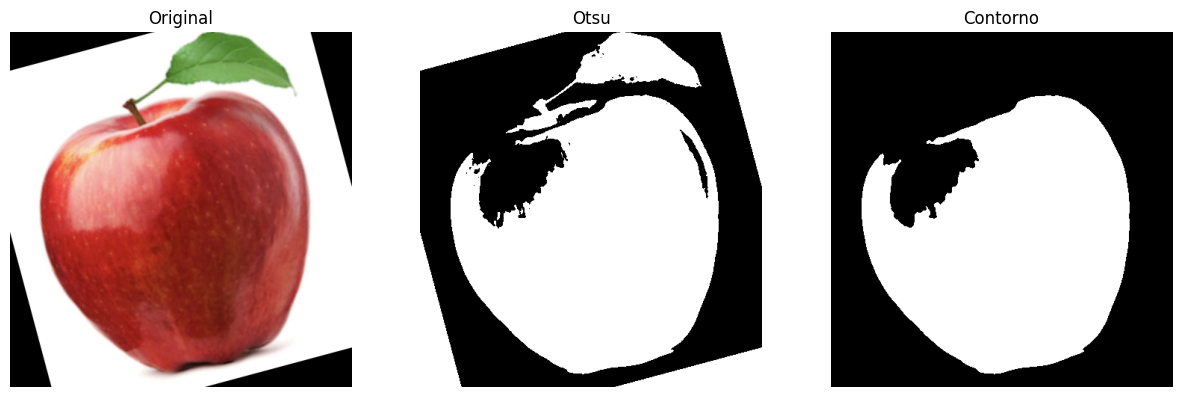

In [10]:
# Comparação entre os métodos de segmentação
# Esta etapa permite comparar visualmente os resultados obtidos pelos dois métodos implementados:
# - Otsu: segmentação por limiarização automática
# - Contorno: segmentação baseada na extração do maior contorno

# Carrega uma imagem de exemplo do dataset
img = cv2.imread(image_paths[0])

# Converte de BGR para RGB para exibição correta
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Aplica os dois métodos de segmentação
mask1 = segmentar_otsu(img)
mask2 = segmentar_contorno(img)

# Exibe a imagem original e os resultados obtidos
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(img)
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(mask1, cmap="gray")
plt.title("Otsu")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(mask2, cmap="gray")
plt.title("Contorno")
plt.axis("off")

plt.show()

In [11]:
# Função final de segmentação de frutas

# Esta função aplica a segmentação baseada em contornos e, em seguida, utiliza a máscara gerada para "recortar" a fruta na imagem original
# O resultado mantém apenas os pixels da região segmentada, removendo o fundo
def segmentar_fruta(imagem):
    # Gera a máscara da fruta utilizando o método de contornos
    mask = segmentar_contorno(imagem)

    # Aplica a máscara na imagem original, preservando apenas a região de interesse (fruta)
    resultado = cv2.bitwise_and(imagem, imagem, mask=mask)

    return resultado

In [12]:
# Aplicação da segmentação em todo o dataset
# Esta etapa percorre todas as imagens do dataset, aplica a segmentação final da fruta e salva os resultados em disco
# Além disso, registra os nomes dos arquivos gerados junto com seus respectivos rótulos para futuras análises

# Lista para armazenar informações das imagens processadas
dados = []

# Percorre todas as imagens do dataset
for i, caminho in enumerate(image_paths):
    # Leitura da imagem (OpenCV lê em BGR)
    img = cv2.imread(caminho)

    # Conversão para RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Aplica a segmentação final (recorte da fruta)
    segmentada = segmentar_fruta(img)

    # Define o nome do arquivo de saída
    nome_saida = f"fruit_{i}.png"

    # Caminho completo onde a imagem será salva
    caminho_saida = os.path.join(OUTPUT_PATH, nome_saida)

    # Converte RGB → BGR antes de salvar (formato OpenCV)
    cv2.imwrite(caminho_saida, cv2.cvtColor(segmentada, cv2.COLOR_RGB2BGR))

    # Armazena o nome do arquivo e seu rótulo correspondente
    dados.append([nome_saida, labels[i]])

# Confirmação da conclusão do processo
print("Segmentação concluída.")

Segmentação concluída.


In [13]:
# Salvamento das informações das classes em CSV
# Esta etapa cria um arquivo CSV contendo o mapeamento entre os arquivos gerados após a segmentação e suas respectivas
# classes (rótulos originais do dataset)
# Esse arquivo é útil para futuras etapas de análise, treinamento de modelos ou validação dos resultados

# Criação do DataFrame com os dados coletados
df = pd.DataFrame(
    dados,
    columns=[
        "arquivo",
        "classe"
    ]
)

# Salvamento do DataFrame em arquivo CSV
df.to_csv("../outputs/classes.csv", index=False)

# Confirmação do salvamento
print("classes.csv salvo.")

classes.csv salvo.


In [14]:
# Verificação do arquivo CSV gerado
# Esta etapa realiza a leitura do arquivo classes.csv para confirmar se os dados foram salvos corretamente e verificar rapidamente sua estrutura

# Carrega o arquivo CSV com as informações das classes
df = pd.read_csv("../outputs/classes.csv")


# Exibe as primeiras linhas do DataFrame para inspeção
df.head()

,arquivo,classe
0,fruit_0.png,freshapples
1,fruit_1.png,freshapples
2,fruit_2.png,freshapples
3,fruit_3.png,freshapples
4,fruit_4.png,freshapples
